# importing required libraries

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

## Data is splitted to training, validation and test folders

In [ ]:
# Splitting the dataset into training, validation and test folders 
import splitfolders
input_folder="sign_language_interpreter/dataset - Gesture Speech"
output="sign_language_interpreter/dataset - Gesture Speech/Processed_data"
splitfolders.ratio(input_folder,output,seed=42,ratio=(.6,.2,.2))

# Data augmentation and Data preprocessing 

In [22]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Data loading

In [23]:
#reading files from the training folder
train_generator = train_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# reading files from validation folder
val_generator = val_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
# reading files from test folder
test_generator = test_datagen.flow_from_directory(
    "sign_language_interpreter/dataset - Gesture Speech/Processed_data/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18720 images belonging to 26 classes.
Found 6240 images belonging to 26 classes.
Found 6240 images belonging to 26 classes.


# Creating the model with the pre-trained model weights(MobileNetV2)

In [24]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([

    Input(shape=(224,224,3)),

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(
        train_generator.num_classes,
        activation='softmax'
    )
])

# Compile the model

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.9785 - loss: 0.0629 - val_accuracy: 0.9788 - val_loss: 0.0622
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 343s 586ms/step - accuracy: 0.9764 - loss: 0.0681 - val_accuracy: 0.9806 - val_loss: 0.0618
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 338s 578ms/step - accuracy: 0.9765 - loss: 0.0669 - val_accuracy: 0.9705 - val_loss: 0.0909
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 341s 582ms/step - accuracy: 0.9783 - loss: 0.0659 - val_accuracy: 0.9755 - val_loss: 0.0874
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 340s 582ms/step - accuracy: 0.9819 - loss: 0.0554 - val_accuracy: 0.9814 - val_loss: 0.0652
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 355s 607ms/step - accuracy: 0.9787 - loss: 0.0648 - val_accuracy: 0.9699 - val_loss: 0.1140
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 343s 586ms/step - accuracy: 0.9827 - loss: 0.0536 - val_accuracy: 0.9731 - val_loss: 0.0959
Epoch 8/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 341s 583ms/step - accuracy: 0.9829 - lo

# Model Evaluation

In [28]:
model.evaluate(test_generator)

195/195 ━━━━━━━━━━━━━━━━━━━━ 109s 559ms/step - accuracy: 0.9684 - loss: 0.1363


[0.13628210127353668, 0.9684295058250427]

# Model Prediction

In [29]:
# predicting the labels
y_predict=model.predict(test_generator)

195/195 ━━━━━━━━━━━━━━━━━━━━ 62s 311ms/step


In [30]:
y_predict[0]

array([1.0000000e+00, 5.3407066e-15, 1.3556695e-21, 1.4546234e-25,
       1.8388849e-19, 1.6430344e-21, 1.6330461e-17, 7.3140567e-18,
       7.3609455e-24, 1.8538117e-17, 5.8281370e-26, 8.6572067e-26,
       1.9665786e-17, 2.7462097e-26, 6.1514688e-18, 5.5260359e-19,
       1.3754138e-18, 1.2081629e-25, 3.9552636e-20, 1.4738736e-22,
       1.2698036e-28, 1.0384221e-27, 3.6944358e-22, 8.5996418e-18,
       3.7221067e-29, 4.1195689e-23], dtype=float32)

In [32]:
# using argmax, class label of the maximum array of each input is returned
import numpy as np
y_predicts=np.argmax(y_predict, axis=1)

In [33]:
y_predicts[2000:2010]

array([8, 8, 8, 8, 8, 8, 8, 8, 8, 8], dtype=int64)

In [34]:
predicted_letters = [chr(i + ord('A')) for i in y_predicts]

In [35]:
print(predicted_letters[2000:2010])

['I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I']


In [36]:
class_names=train_generator.class_indices
class_names

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25}

# Saving the class file

In [37]:
import numpy as np
np.save("class_indices_mob.npy", class_names)

# Confusion Matrix

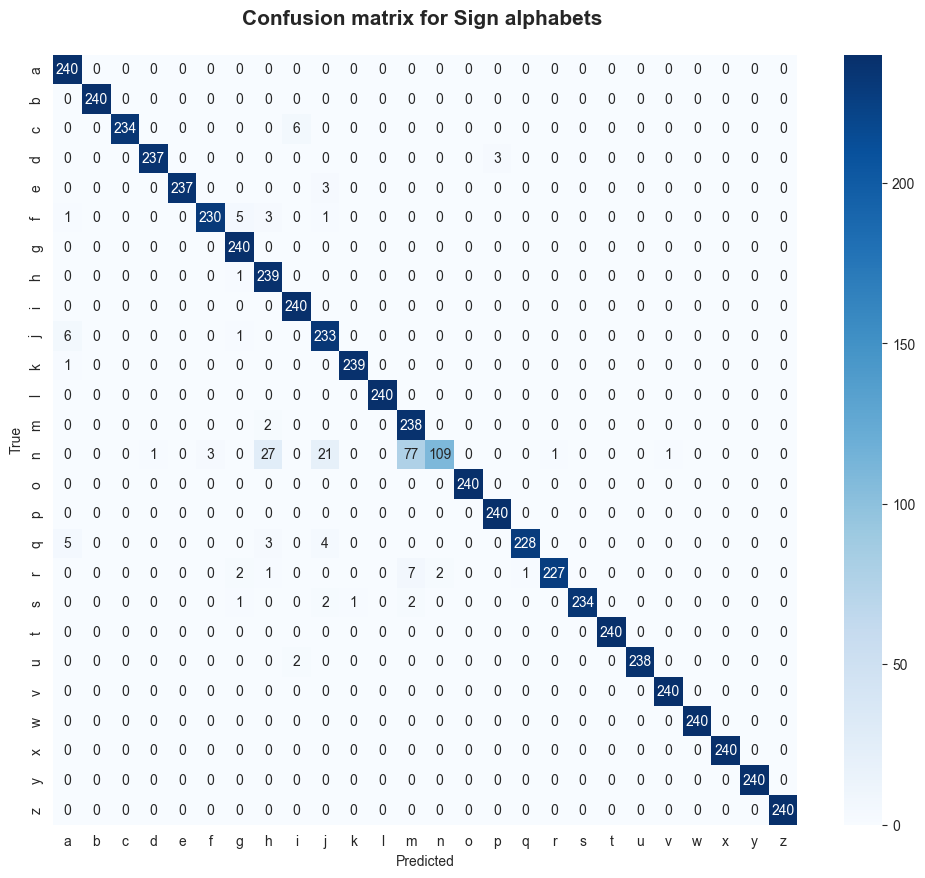

In [43]:
# confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
# True labels from your dataset
true_classes = test_generator.classes
con_mat=confusion_matrix(true_classes,y_predicts)
#visualizing confusion matrix
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('deep')
# mentioning the plot size for displaying true and predicted values
plt.figure(figsize=(12,10))
sns.heatmap(con_mat,annot=True,fmt="d",cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix for Sign alphabets \n", fontweight='bold',fontsize=15)
plt.show()

# Classification Report

In [44]:
print(classification_report(true_classes,y_predicts))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       240
           1       1.00      1.00      1.00       240
           2       1.00      0.97      0.99       240
           3       1.00      0.99      0.99       240
           4       1.00      0.99      0.99       240
           5       0.99      0.96      0.97       240
           6       0.96      1.00      0.98       240
           7       0.87      1.00      0.93       240
           8       0.97      1.00      0.98       240
           9       0.88      0.97      0.92       240
          10       1.00      1.00      1.00       240
          11       1.00      1.00      1.00       240
          12       0.73      0.99      0.84       240
          13       0.98      0.45      0.62       240
          14       1.00      1.00      1.00       240
          15       0.99      1.00      0.99       240
          16       1.00      0.95      0.97       240
          17       1.00    

# Saving the model

In [45]:
model.save("sign_alphabet_mob_model.keras")

In [46]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation accuracy:", val_acc)

195/195 ━━━━━━━━━━━━━━━━━━━━ 107s 551ms/step - accuracy: 0.9728 - loss: 0.1154
Validation accuracy: 0.9727563858032227
